In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np
from Seera_init import tensor as Tensor
import matplotlib.pyplot as plt
from Seera import (
    Input, Conv2D, MaxPool2D, Flatten, Dense,
    Sequential, Loss, Adam,
)

2026-04-09 01:36:37.828155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 01:36:38.378068: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-09 01:36:39.888191: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train_ = np.expand_dims(X_train,axis=1)/255
y_train_ = np.zeros((60000,10))
for i in range (0,60000):
    y_train_[i,:] = np.eye(1,10,y_train[i])
    
X_test_ = np.expand_dims(X_test,axis=1)/255


In [3]:
X_train_.shape

(60000, 1, 28, 28)

[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


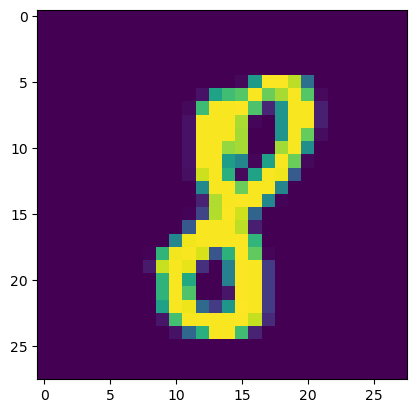

In [4]:
i = np.random.randint(0,60000)
plt.imshow(X_train_[i,0,:,:])
print(y_train_[i])
# print(np.eye(1,10,y_train[i]))

In [ ]:
print("=" * 60)
print("  MNIST GPU Test — Seera Framework (CUDA)")
print("=" * 60)

print(f"Train: {X_train.shape}, Test: {y_test.shape}")

# ─── Build Model (device="cuda") ─────────────────────────
model = Sequential([
    Input((1, 28, 28)),
    Conv2D(8, 1, (3, 3), activation="relu", stride=1, zero_padding=1),
    MaxPool2D(pool_size=(2, 2), stride=2),
    Conv2D(16, 8, (3, 3), activation="relu", stride=1, zero_padding=1),
    MaxPool2D(pool_size=(2, 2), stride=2),
    Flatten(),
    Dense(16 * 7 * 7, 64, activation="relu"),
    Dense(64, 10, activation="softmax"),
], device="cuda")
model.summary()

# ─── Train ───────────────────────────────────────────────
loss_fn = Loss()
optimizer = Adam(model, lr=0.001)

history = model.fit(
    X_train_, y_train_,
    Optimizer=optimizer,
    Loss=loss_fn.categorical_cross_entropy,
    Epochs=5,
    batch_size=16,
    Loss_interval=1,
)

# ─── Evaluate ────────────────────────────────────────────
correct = 0
for i in range(len(X_test)):
    x = Tensor(X_test_[i:i+1], is_leaf=True, device="cuda")
    pred = model.predict(x)
    # bring to host for argmax
    pred_np = pred.value.to_host_f32()
    pred_label = np.argmax(pred_np)
    if pred_label == y_test[i]:
        correct += 1

accuracy = correct / len(X_test) * 100
print(f"\nTest Accuracy: {accuracy:.1f}% ({correct}/{len(X_test)})")
print("GPU test complete ✓")

  MNIST GPU Test — Seera Framework (CUDA)
Train: (60000, 28, 28), Test: (10000,)
Model Summary
  Layer 0: Input Layer with shape (1, 28, 28)
  Layer 1: Conv2D(1→8, kernel=(3, 3), act=relu)
  Layer 2: MaxPool2D(pool=(2, 2), stride=(2, 2))
  Layer 3: Conv2D(8→16, kernel=(3, 3), act=relu)
  Layer 4: MaxPool2D(pool=(2, 2), stride=(2, 2))
  Layer 5: Flatten Layer
  Layer 6: Dense(784→64, act=relu, params=50240)
  Layer 7: Dense(64→10, act=softmax, params=650)


In [ ]:
correct = 0
for i in range(len(X_test)):
    x = Tensor(X_test_[i:i+1], is_leaf=True, device="cuda")
    pred = model.predict(x)
    print(pred)
    # bring to host for argmax
    pred_np = pred.value.to_host_f32()
    pred_label = np.argmax(pred_np)
    if pred_label == y_test[i]:
        correct += 1

accuracy = correct / len(X_test) * 100
print(f"\nTest Accuracy: {accuracy:.1f}% ({correct}/{len(X_test)})")
print("GPU test complete ✓")